# Differentiation

In [127]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')


def parse_params(folder_name):
    """
    Example:
    n_10_rq_1_v0_1 -> {"n": 10, "rq": 1, "v0": 1}
    """
    parts = folder_name.split("_")
    params = {}

    for i in range(0, len(parts) - 1, 2):
        key = parts[i]
        val = parts[i + 1]

        try:
            params[key] = float(val)
        except ValueError:
            pass

    return params


def analyze_h5(h5_path):
    with h5py.File(h5_path, "r") as f:
        psi = f["solution/psi_hist"][-1]
        qx = f["solution/qx_hist"][-1]
        qy = f["solution/qy_hist"][-1]

    qmag = np.sqrt(qx**2 + qy**2)

    area_psi = np.mean(0.5 * (np.clip(psi, -1, 1) + 1))
    area_q = np.mean(qmag)

    return {
        "area_psi": area_psi,
        "area_q": area_q,
        "max_psi": np.max(psi),
        "has_diff": np.any(psi > 0.9),
    }


def scan(base_dir):
    rows = []

    for param_folder in sorted(os.listdir(base_dir)):
        param_dir = os.path.join(base_dir, param_folder)

        if not os.path.isdir(param_dir):
            continue

        params = parse_params(param_folder)

        for sim_folder in sorted(os.listdir(param_dir)):
            sim_dir = os.path.join(param_dir, sim_folder)

            if not os.path.isdir(sim_dir):
                continue

            h5_files = [f for f in os.listdir(sim_dir) if f.endswith(".h5")]
            if not h5_files:
                continue

            h5_path = os.path.join(sim_dir, h5_files[0])
            obs = analyze_h5(h5_path)

            row = {
                "param_folder": param_folder,
                "sim_folder": sim_folder,
                "h5_path": h5_path,
            }

            row.update(params)
            row.update(obs)
            rows.append(row)

    return pd.DataFrame(rows)


def plot_area_vs_nb(df, rq, v0, y="area_psi"):
    # Filter dataset
    df_sub = df[(df["rq"] == rq) & (df["v0"] == v0)]

    if df_sub.empty:
        raise ValueError("No data for given rq and v0")

    # Group by number of beads
    grouped = df_sub.groupby("nb")[y].mean()

    # fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(
        grouped.index,
        grouped.values,
        "o-", 
        label=f"rq={rq}, v0={v0}"
    )

    # return fig, ax



def plot_vs(df, xparam, y="area_psi"):
    grouped = df.groupby(xparam)[y]

    mean = grouped.mean()
    std = grouped.std()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.errorbar(
        mean.index,
        mean.values,
        yerr=std.values,
        fmt="o-",
        capsize=3,
    )

    ax.set_xlabel(xparam)
    ax.set_ylabel(y)
    ax.grid()
    ax.set_ylim(-0.1, 1.1)

    return fig, ax

,param_folder,sim_folder,h5_path,nb,rq,v0,area_psi,area_q,max_psi,has_diff
0,nb_100_rq_0.0_v0_0.0,sim_data_20260504_202756,outputs/homo_speed_rq_sweep\nb_100_rq_0.0_v0_0...,100.0,0.0,0.0,1.776357e-15,0.195497,-1.000000,False
1,nb_100_rq_0.0_v0_0.0,sim_data_20260504_202853,outputs/homo_speed_rq_sweep\nb_100_rq_0.0_v0_0...,100.0,0.0,0.0,1.776357e-15,0.196608,-1.000000,False
2,nb_100_rq_0.0_v0_0.0,sim_data_20260504_202949,outputs/homo_speed_rq_sweep\nb_100_rq_0.0_v0_0...,100.0,0.0,0.0,1.776357e-15,0.200020,-1.000000,False
3,nb_100_rq_0.0_v0_3.0,sim_data_20260504_203046,outputs/homo_speed_rq_sweep\nb_100_rq_0.0_v0_3...,100.0,0.0,3.0,5.219409e-02,0.264995,1.312015,True
4,nb_100_rq_0.0_v0_3.0,sim_data_20260504_203153,outputs/homo_speed_rq_sweep\nb_100_rq_0.0_v0_3...,100.0,0.0,3.0,2.040860e-02,0.223318,1.235875,True
...,...,...,...,...,...,...,...,...,...,...
158,nb_9_rq_1.0_v0_3.0,sim_data_20260504_153102,outputs/homo_speed_rq_sweep\nb_9_rq_1.0_v0_3.0...,9.0,1.0,3.0,1.985418e-15,0.001131,-1.000000,False
159,nb_9_rq_1.0_v0_3.0,sim_data_20260504_153214,outputs/homo_speed_rq_sweep\nb_9_rq_1.0_v0_3.0...,9.0,1.0,3.0,1.987607e-15,0.000929,-1.000000,False
160,nb_9_rq_1.0_v0_5.0,sim_data_20260504_153322,outputs/homo_speed_rq_sweep\nb_9_rq_1.0_v0_5.0...,9.0,1.0,5.0,3.338540e-15,0.001259,-1.000000,False
161,nb_9_rq_1.0_v0_5.0,sim_data_20260504_153517,outputs/homo_speed_rq_sweep\nb_9_rq_1.0_v0_5.0...,9.0,1.0,5.0,3.368223e-15,0.001545,-1.000000,False


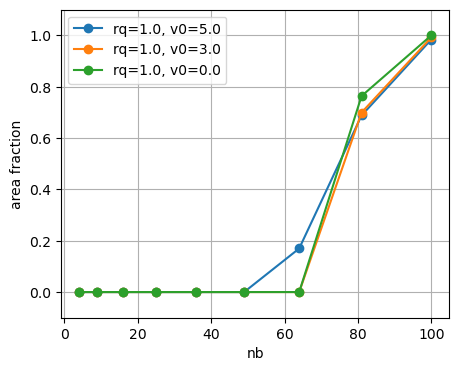

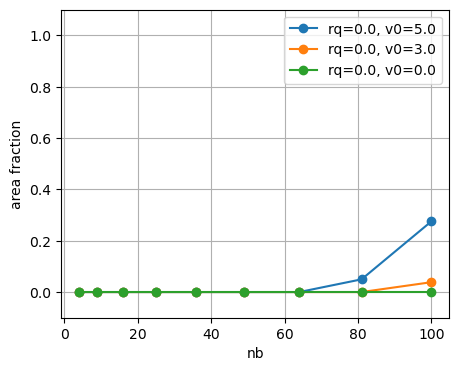

In [126]:
base_dir = "outputs/homo_speed_rq_sweep"

df = scan(base_dir)

display(df)

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=1.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=0.0, y="area_psi")


ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)

plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=0.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=0.0, y="area_psi")

ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)

plt.legend()
plt.show()


,param_folder,sim_folder,h5_path,nb,rq,v0,area_psi,area_q,max_psi,has_diff
0,nb_100_rq_0.0_v0_0.0,sim_data_20260504_141931,outputs/pol_speed_rq_sweep\nb_100_rq_0.0_v0_0....,100.0,0.0,0.0,3.197557e-01,0.373462,1.000000,True
1,nb_100_rq_0.0_v0_0.0,sim_data_20260504_142029,outputs/pol_speed_rq_sweep\nb_100_rq_0.0_v0_0....,100.0,0.0,0.0,3.197557e-01,0.373485,1.000000,True
2,nb_100_rq_0.0_v0_0.0,sim_data_20260504_142127,outputs/pol_speed_rq_sweep\nb_100_rq_0.0_v0_0....,100.0,0.0,0.0,3.197557e-01,0.373561,1.000000,True
3,nb_100_rq_0.0_v0_3.0,sim_data_20260504_142224,outputs/pol_speed_rq_sweep\nb_100_rq_0.0_v0_3....,100.0,0.0,3.0,3.894352e-01,0.677119,1.299137,True
4,nb_100_rq_0.0_v0_3.0,sim_data_20260504_142332,outputs/pol_speed_rq_sweep\nb_100_rq_0.0_v0_3....,100.0,0.0,3.0,5.610252e-01,0.717788,1.293209,True
...,...,...,...,...,...,...,...,...,...,...
157,nb_9_rq_1.0_v0_3.0,sim_data_20260504_114716,outputs/pol_speed_rq_sweep\nb_9_rq_1.0_v0_3.0\...,9.0,1.0,3.0,1.634618e-15,0.004530,-1.000000,False
158,nb_9_rq_1.0_v0_3.0,sim_data_20260504_114831,outputs/pol_speed_rq_sweep\nb_9_rq_1.0_v0_3.0\...,9.0,1.0,3.0,1.545666e-15,0.005283,-1.000000,False
159,nb_9_rq_1.0_v0_5.0,sim_data_20260504_114942,outputs/pol_speed_rq_sweep\nb_9_rq_1.0_v0_5.0\...,9.0,1.0,5.0,3.111413e-15,0.004508,-1.000000,False
160,nb_9_rq_1.0_v0_5.0,sim_data_20260504_115139,outputs/pol_speed_rq_sweep\nb_9_rq_1.0_v0_5.0\...,9.0,1.0,5.0,2.915454e-15,0.005012,-1.000000,False


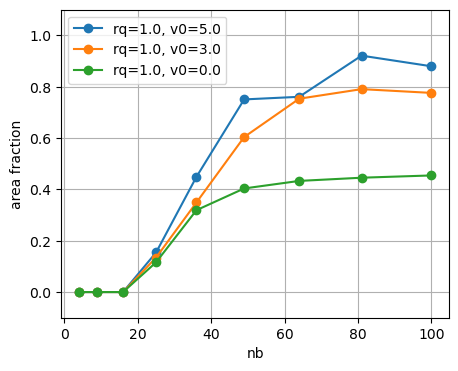

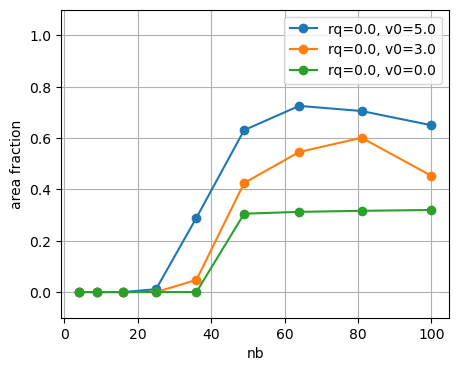

In [129]:
base_dir = "outputs/pol_speed_rq_sweep"

df = scan(base_dir)

display(df)

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=1.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=0.0, y="area_psi")


ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)
ax.grid()
plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=0.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=0.0, y="area_psi")

ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)
ax.grid()
plt.legend()
plt.show()


# one bead

In [153]:
base_dir = "outputs/one_bead"

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

df = scan(base_dir)

display(df)

,param_folder,sim_folder,h5_path,dpsi,rm,sig,rq,v0,area_psi,area_q,max_psi,has_diff
0,dpsi_0.001_rm_0.1_sig_0.01_rq_0.0_v0_0.0,sim_data_20260505_001744,outputs/one_bead\dpsi_0.001_rm_0.1_sig_0.01_rq...,0.001,0.1,0.01,0.0,0.0,0.000000,0.000000,-1.000000,False
1,dpsi_0.001_rm_0.1_sig_0.01_rq_0.0_v0_3.0,sim_data_20260505_001754,outputs/one_bead\dpsi_0.001_rm_0.1_sig_0.01_rq...,0.001,0.1,0.01,0.0,3.0,0.000000,0.000000,-1.000000,False
2,dpsi_0.001_rm_0.1_sig_0.01_rq_0.0_v0_5.0,sim_data_20260505_001845,outputs/one_bead\dpsi_0.001_rm_0.1_sig_0.01_rq...,0.001,0.1,0.01,0.0,5.0,0.000000,0.000000,-1.000000,False
3,dpsi_0.001_rm_0.1_sig_0.01_rq_1.0_v0_0.0,sim_data_20260505_002022,outputs/one_bead\dpsi_0.001_rm_0.1_sig_0.01_rq...,0.001,0.1,0.01,1.0,0.0,0.000000,0.000000,-1.000000,False
4,dpsi_0.001_rm_0.1_sig_0.01_rq_1.0_v0_3.0,sim_data_20260505_002034,outputs/one_bead\dpsi_0.001_rm_0.1_sig_0.01_rq...,0.001,0.1,0.01,1.0,3.0,0.000000,0.000000,-1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...
283,dpsi_1.0_rm_0.5_sig_2.0_rq_0.0_v0_3.0,sim_data_20260505_122615,outputs/one_bead\dpsi_1.0_rm_0.5_sig_2.0_rq_0....,1.000,0.5,2.00,0.0,3.0,0.082320,0.171010,-0.513203,False
284,dpsi_1.0_rm_0.5_sig_2.0_rq_0.0_v0_5.0,sim_data_20260505_122809,outputs/one_bead\dpsi_1.0_rm_0.5_sig_2.0_rq_0....,1.000,0.5,2.00,0.0,5.0,0.635241,0.388871,1.202469,True
285,dpsi_1.0_rm_0.5_sig_2.0_rq_1.0_v0_0.0,sim_data_20260505_123047,outputs/one_bead\dpsi_1.0_rm_0.5_sig_2.0_rq_1....,1.000,0.5,2.00,1.0,0.0,1.000000,0.799447,1.000000,True
286,dpsi_1.0_rm_0.5_sig_2.0_rq_1.0_v0_3.0,sim_data_20260505_123248,outputs/one_bead\dpsi_1.0_rm_0.5_sig_2.0_rq_1....,1.000,0.5,2.00,1.0,3.0,0.932073,0.727390,1.121931,True


(<Figure size 500x400 with 2 Axes>,
 <Axes: title={'center': "{'v0': 0.0, 'rq': 1.0, 'dpsi': 1.0}"}, xlabel='$r_m$', ylabel='$\\sigma$'>)

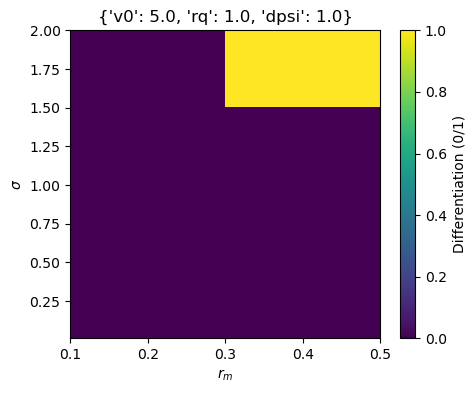

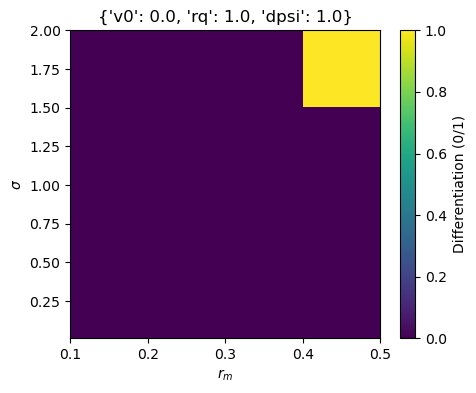

In [159]:
df["differentiated"] = df["has_diff"].astype(float)

def plot_binary_phase(df, x, y, fixed):
    d = df.copy()

    for k, v in fixed.items():
        d = d[d[k] == v]

    table = d.pivot_table(
        index=y,
        columns=x,
        values="has_diff",
        aggfunc="mean"  # will be 0 or 1 since single run
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(
        table.values,
        origin="lower",
        aspect="auto",
        extent=[
            table.columns.min(), table.columns.max(),
            table.index.min(), table.index.max()
        ],
        vmin=0,
        vmax=1
    )

    ax.set_xlabel(f"$r_m$")
    ax.set_ylabel(f"$\sigma$")
    ax.set_title(str(fixed))

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Differentiation (0/1)")

    return fig, ax

plot_binary_phase(
    df,
    x="rm",
    y="sig",
    fixed={"v0": 5.0, "rq": 1.0, "dpsi": 1.0}
)


plot_binary_phase(
    df,
    x="rm",
    y="sig",
    fixed={"v0": 0.0, "rq": 1.0, "dpsi": 1.0}
)

